# 0. 환경 점검 + 경로 정의

### 0-1. 환경 & 경로

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

PROJECT  = Path(r'D:\02.study\part4_wj\Battery\Battery_Project')
ONNX_OUT = PROJECT / 'models' / 'battery_deeplab_v2.onnx'
IMG_DIR  = PROJECT / 'battery_image'
MASK_DIR = PROJECT / 'battery_mask'
SPLIT    = PROJECT / 'battery_splits' / 'test_meta.csv'
DEMO_DIR = PROJECT / 'notebooks_docs' / 'Demo_Image'
REPORT   = PROJECT / 'docs' / '09_re_verification_report.md'

for p in [ONNX_OUT, IMG_DIR, MASK_DIR, SPLIT]:
    assert p.exists(), f'경로 없음: {p}'
DEMO_DIR.mkdir(parents=True, exist_ok=True)

# 클래스 정의 — 학습 인덱스와 1:1 일치 (data_card.md §3)
CLASS_NAMES = ['background', 'Pollution', 'Damaged']
NUM_CLASSES = 3
# 시각화 팔레트 (RGB) — Pollution=노랑, Damaged=빨강
PALETTE = np.array([[0, 0, 0], [255, 255, 0], [255, 0, 0]], dtype=np.uint8)

# 한글 깨짐 마이너스 부호 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print('경로 확인 완료')

경로 확인 완료


## 1. test 셋 로드 + 분포 확인

모집단 `test_meta.csv`로 검증 대상 38장을 불러오고, clean / pollution / both 분포를 출력합니다.

### 1-1. test 셋 로드

In [4]:
df = pd.read_csv(SPLIT)                       # 컬럼: name, label
df['img']  = df['name'].apply(lambda n: IMG_DIR  / f'{n}.png')
df['mask'] = df['name'].apply(lambda n: MASK_DIR / f'{n}.png')

# 파일 존재 검증 — 하나라도 없으면 즉시 멈춤
missing = df[~df['img'].apply(Path.exists) | ~df['mask'].apply(Path.exists)]
assert missing.empty, f'누락 파일:\n{missing["name"].tolist()}'

print(f'test 셋: {len(df)}장')
print(df['label'].value_counts())

ok_df = df[df['label'] == 'clean'].reset_index(drop=True)       # 정상품 24
defect_df = df[df['label'].isin(['pollution', 'both'])].reset_index(drop=True)  # 결함 14
print(f'\n정상품(OK): {len(ok_df)}장   결함: {len(defect_df)}장')

test 셋: 38장
label
clean        24
both          7
pollution     7
Name: count, dtype: int64

정상품(OK): 24장   결함: 14장


## 2. ONNX 추론 함수

추론 엔진을 구성하기 위해

C# `Postprocessor.cs`와 **완전히 동일한 전처리**로 추론하는 함수를 만듭니다.

### 2-1. (GPU 사용 시) NVIDIA 런타임 DLL 경로 등록

In [5]:
import os
NVIDIA_BIN = PROJECT / 'venv_battery' / 'Lib' / 'site-packages' / 'nvidia'
for sub in ['cudnn', 'cuda_runtime', 'cublas']:
    d = str(NVIDIA_BIN / sub / 'bin')
    if Path(d).is_dir():
        os.add_dll_directory(d)
        os.environ['PATH'] = d + os.pathsep + os.environ['PATH']
        print(f'CUDA DLL dir added: {d}')

CUDA DLL dir added: D:\02.study\part4_wj\Battery\Battery_Project\venv_battery\Lib\site-packages\nvidia\cudnn\bin
CUDA DLL dir added: D:\02.study\part4_wj\Battery\Battery_Project\venv_battery\Lib\site-packages\nvidia\cuda_runtime\bin
CUDA DLL dir added: D:\02.study\part4_wj\Battery\Battery_Project\venv_battery\Lib\site-packages\nvidia\cublas\bin


### 2-2. ORT 세션 생성

In [6]:
import onnxruntime as ort

sess = ort.InferenceSession(
    str(ONNX_OUT),
    providers=['CUDAExecutionProvider', 'CPUExecutionProvider'],
)
INPUT_NAME  = sess.get_inputs()[0].name
OUTPUT_NAME = sess.get_outputs()[0].name
print(f'입력: {INPUT_NAME}  출력: {OUTPUT_NAME}')
print(f'실제 사용 provider: {sess.get_providers()}')

입력: input  출력: logits
실제 사용 provider: ['CUDAExecutionProvider', 'CPUExecutionProvider']


> `CUDAExecutionProvider`가 결과로 나왔으니 GPU 를 사용하고 있는 상태임을 확인하였습니다.

### 2-3. 전처리 + 추론 함수

In [7]:
SIZE = 513
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def _softmax(logits, axis=0):
    e = np.exp(logits - logits.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

def predict(img_path):
    """원본 이미지 → (클래스 마스크[H,W], 클래스 확률[3,H,W]). 모두 원본 해상도."""
    bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(img_path)
    H, W = bgr.shape[:2]

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (SIZE, SIZE), interpolation=cv2.INTER_LINEAR)
    x = resized.astype(np.float32) / 255.0
    x = (x - MEAN) / STD                          # ImageNet 정규화
    x = x.transpose(2, 0, 1)[None]                # HWC → NCHW

    logits = sess.run([OUTPUT_NAME], {INPUT_NAME: x})[0][0]   # (3,513,513)
    prob513 = _softmax(logits, axis=0)
    cls513  = logits.argmax(0).astype(np.uint8)

    # 원본 해상도 복원 — 클래스는 nearest(인덱스 보존), 확률은 linear
    cls_full  = cv2.resize(cls513, (W, H), interpolation=cv2.INTER_NEAREST)
    prob_full = np.stack([cv2.resize(prob513[c], (W, H), interpolation=cv2.INTER_LINEAR) for c in range(NUM_CLASSES)], axis=0)
    
    return cls_full, prob_full

# 동작 확인 — 결함 1장
_cls, _prob = predict(defect_df.loc[0, 'img'])
print(f'예측 마스크 shape={_cls.shape}, 클래스값={np.unique(_cls)}')

예측 마스크 shape=(1080, 1920), 클래스값=[0 1 2]


## 3. DL 정상품 과검 검증

학습에 쓰이지 않은 **정상품 24장**을 추론합니다.

정답 마스크가 전부 background인 이미지에서 **모델이 결함 픽셀을 얼마나 잘못 잡는지(과검)** 를 측정합니다.

### 3-1. 정상품 과검 측정

In [8]:
MIN_DEFECT_AREA = 100   # 이 픽셀 수 미만은 노이즈로 보고 과검에서 제외 (EDA Pollution 중앙값 139px)
TOTAL_PX = 1920 * 1080

rows = []
for _, r in ok_df.iterrows():
    cls, _ = predict(r['img'])
    poll_px = int((cls == 1).sum())
    dmg_px  = int((cls == 2).sum())
    defect_px = poll_px + dmg_px
    rows.append({'name': r['name'], 'Pollution_px': poll_px,
                 'Damaged_px': dmg_px, 'defect_px': defect_px,
                 'overkill': defect_px >= MIN_DEFECT_AREA})

ok_res = pd.DataFrame(rows)
n_overkill = int(ok_res['overkill'].sum())
overkill_rate = n_overkill / len(ok_res)

print(f'정상품 {len(ok_res)}장 중 과검 {n_overkill}장  (과검율 {overkill_rate*100:.1f}%)')
print(f'정상품 평균 오검 픽셀: {ok_res["defect_px"].mean():.0f} px '
      f'(전체 {TOTAL_PX:,}px 대비 {ok_res["defect_px"].mean()/(TOTAL_PX)*100:.3f}%)')
print('\n과검 발생 이미지 (defect_px 큰 순 상위 5):')
print(ok_res.sort_values('defect_px', ascending=False).head())

정상품 24장 중 과검 24장  (과검율 100.0%)
정상품 평균 오검 픽셀: 3635 px (전체 2,073,600px 대비 0.175%)

과검 발생 이미지 (defect_px 큰 순 상위 5):
                             name  Pollution_px  Damaged_px  defect_px  \
21  RGB_cell_cylindrical_1154_284          7591        1654       9245   
3   RGB_cell_cylindrical_1156_275          7088        1235       8323   
23  RGB_cell_cylindrical_1154_187          7183         424       7607   
22  RGB_cell_cylindrical_1155_099          5233         987       6220   
10  RGB_cell_cylindrical_1156_267          3938        1079       5017   

    overkill  
21      True  
3       True  
23      True  
22      True  
10      True  


### 3-2. 후처리 적용 후 과검 재측정

3-1의 raw 출력은 픽셀 단위 분류기 특성상 노이즈가 섞여 과검율 100%로 나왔습니다.

**① morphological opening** 으로 점 노이즈를 지우고,

**② connected components 의 최소 면적 필터** 로 작은 블롭을 제거한 뒤 다시 측정합니다.

### 3-2-1. 후처리 함수 정의 (morphology + 면적 필터)

In [9]:
# 후처리 하이퍼파라미터 (튜닝 포인트)
KERNEL_SIZE = 3       # opening 커널 크기 — 클수록 더 공격적으로 노이즈 제거
MIN_AREA    = 500     # 결함으로 인정할 최소 블롭 면적(px)

KERNEL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (KERNEL_SIZE, KERNEL_SIZE))

def postprocess(cls, min_area=MIN_AREA, kernel=KERNEL):
    """
    raw 클래스 마스크 → 정제된 클래스 마스크.
    1) 클래스별 이진 마스크로 분리
    2) morphological opening 으로 점 노이즈 제거
    3) connected components 후 min_area 미만 블롭 제거
    """
    cleaned = np.zeros_like(cls)
    for c in [1, 2]:                                          # background(0) 제외
        bin_mask = (cls == c).astype(np.uint8)
        opened   = cv2.morphologyEx(bin_mask, cv2.MORPH_OPEN, kernel)
        n, labels, stats, _ = cv2.connectedComponentsWithStats(opened, connectivity=8)
        for i in range(1, n):                                 # 0번은 배경
            if stats[i, cv2.CC_STAT_AREA] >= min_area:
                cleaned[labels == i] = c
    return cleaned

# 동작 확인 — 결함 1장
_cls, _ = predict(defect_df.loc[0, 'img'])
_pp = postprocess(_cls)
print(f'raw 결함 픽셀:  {int((_cls > 0).sum()):>7d}')
print(f'후처리 후:     {int((_pp  > 0).sum()):>7d}')

raw 결함 픽셀:    44715
후처리 후:       42957


### 3-2-2. 정상품 24장에 적용 + 재측정 

In [ ]:
TOTAL_PX = 1920 * 1080

rows = []
for _, r in ok_df.iterrows():
    cls, _ = predict(r['img'])
    cls_pp = postprocess(cls)
    poll_px = int((cls_pp == 1).sum())
    dmg_px  = int((cls_pp == 2).sum())
    defect_px = poll_px + dmg_px
    rows.append({'name': r['name'], 'Pollution_px': poll_px,
                 'Damaged_px': dmg_px, 'defect_px': defect_px,
                 'overkill': (poll_px + dmg_px) >0,
                 })

ok_pp = pd.DataFrame(rows)
n_over = int(ok_pp['overkill'].sum())
n_over_rate = n_over / len(ok_pp)
mean_px = ok_pp['defect_px'].mean()


print(f'정상품 {len(ok_pp)}장 중 과검 {n_over}장  (과검율 {n_over_rate*100:.1f}%)')
print(f'정상품 평균 오검 픽셀: {mean_px:.0f} px '
      f'(전체 {TOTAL_PX:,}px 대비 {mean_px/TOTAL_PX*100:.3f}%)')
print('\n과검 발생 이미지 (defect_px 큰 순 상위 5):')
print(ok_pp[ok_pp['overkill']].sort_values('defect_px', ascending=False).head())

후처리(opening + MIN_AREA=500)를 적용했음에도 과검율은 100% → 91.7%(22/24장)로 거의 줄지 않았고,
정상품 평균 오검 픽셀은 약 2,500px(2,457px, 전체 2,073,600px 대비 0.118%) 수준으로 나타났습니다.

상위 과검 이미지의 오검 픽셀 수는 여전히 최대 7,000px대 수준을 기록하고 있습니다 (예: 1154_187 — 7,038px, 1154_284 — 7,020px).

평균 오검 픽셀 수가 이전(약 6,000px)에 비해 절반 이상 줄어든 것을 보면 자잘한 노이즈는 일정 부분 제거되었으나, 과검율이 91.7%로 여전히 높은 이유는 남아있는 노이즈가 단순한 점 노이즈가 아니라 면적이 큰 False Positive 블롭 형태이기 때문입니다. 즉, 현재 설정된 MIN_AREA 면적 필터로는 제거되지 않는 크기(3,000~7,000px 이상)의 과검이 존재한다는 뜻입니다.

따라서 단순 면적·threshold 튜닝만으로는 해결이 어렵다고 판단하여, 다음 단계에서 실제 False Positive가 주로 어느 위치에서 발생하고 있는지 그 특성을 먼저 확인하겠습니다.

### 3-2-3. 워스트 1장 시각화

In [ ]:
# 가장 과검이 심한 1장을 골라 raw vs 후처리 결과를 비교
worst = ok_pp.sort_values('defect_px', ascending=False).iloc[0]['name']
img_path = IMG_DIR / f'{worst}.png'

img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
cls_raw, _ = predict(img_path)
cls_pp     = postprocess(cls_raw)

overlay_raw = img.copy()
overlay_pp  = img.copy()
overlay_raw[cls_raw == 1] = (255, 255, 0)   # Pollution → 노랑
overlay_raw[cls_raw == 2] = (255, 0,   0)   # Damaged   → 빨강
overlay_pp [cls_pp  == 1] = (255, 255, 0)
overlay_pp [cls_pp  == 2] = (255, 0,   0)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(img);          ax[0].set_title(f'Origin: {worst}')
ax[1].imshow(overlay_raw);  ax[1].set_title('raw 예측')
ax[2].imshow(overlay_pp);   ax[2].set_title(f'후처리 (MIN_AREA={MIN_AREA})')
for a in ax: a.axis('off')
plt.tight_layout()
plt.show()

### 3-2-4. 블롭 크기 분포 확인

In [ ]:
ok_blob_sizes = []
for _, r in ok_df.iterrows():
    cls, _ = predict(r['img'])
    cls_pp = postprocess(cls)
    for c in [1, 2]:
        bin_m = (cls_pp == c).astype(np.uint8)
        n, _, stats, _ = cv2.connectedComponentsWithStats(bin_m, connectivity=8)
        for i in range(1, n):
            ok_blob_sizes.append(stats[i, cv2.CC_STAT_AREA])

# 결함 이미지의 진짜 결함 블롭 크기도 같이
defect_blob_sizes = []
for _, r in defect_df.iterrows():
    msk = cv2.imread(str(r['mask']), cv2.IMREAD_GRAYSCALE)
    for c in [1, 2]:
        bin_m = (msk == c).astype(np.uint8)
        n, _, stats, _ = cv2.connectedComponentsWithStats(bin_m, connectivity=8)
        for i in range(1, n):
            defect_blob_sizes.append(stats[i, cv2.CC_STAT_AREA])

print('정상품 false positive 블롭 크기 분포:')
print(pd.Series(ok_blob_sizes).describe())
print('\n결함 GT 블롭 크기 분포:')
print(pd.Series(defect_blob_sizes).describe())

정상품의 False Positive(FP) 블롭과 실제 결함(GT) 블롭의 크기 분포를 비교한 결과는 다음과 같습니다.

- **정상품 FP 블롭**: 최소 500px, 중위수(Median) 1,013px, 최대 6,441px
- **결함 GT 블롭**: 최소 5px, 중위수(Median) 188px, 상위 75%가 768px 이하

분석 결과, 우리가 제거해야 할 정상품 내 오검(FP) 블롭의 크기가 실제 찾아야 하는 결함(GT)의 크기보다 전반적으로 더 크게 나타나는 역전 현상이 확인되었습니다 (FP 중위수 1,013px > GT 중위수 188px). 

이는 단순히 면적(MIN_AREA) 기준을 높여서 FP를 제거하려고 할 경우, 768px 이하의 크기를 갖는 대다수(75% 이상)의 실제 결함까지 함께 필터링되어 대량의 미검(False Negative)이 발생함을 의미합니다.

따라서 단순 크기 기반의 후처리 필터링만으로는 과검과 진짜 결함을 구분하는 데 한계가 있다고 판단됩니다. 면적 이외의 특징을 파악하기 위해, 다음 단계로 육안 검사를 진행하여 실제 FP가 발생하는 위치와 형태적 특성을 바로 확인하겠습니다.

### 3-2-5. 과검 발생 이미지 육안 확인

육안 검사 하며 정확히 확인하기 위해 확대 분석을 진행하였습니다.

In [ ]:
def audit(names, tag):
    print(f'\n========== {tag} : {len(names)}장 ==========')
    for name in names:
        p = IMG_DIR / f'{name}.png'
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        gt  = cv2.imread(str(MASK_DIR / f'{name}.png'), cv2.IMREAD_GRAYSCALE)
        cls, prob = predict(p)
        conf = prob.max(0)
        lab = df.loc[df['name'] == name, 'label'].values[0]

        # 확대 영역: GT 결함이 있으면 GT 기준, 없으면 모델 예측 기준
        ref = gt if (gt > 0).any() else (cls > 0).astype(np.uint8)
        ys, xs = np.where(ref > 0)
        if len(ys):
            m = 110
            y0, y1 = max(0, ys.min()-m), min(img.shape[0], ys.max()+m)
            x0, x1 = max(0, xs.min()-m), min(img.shape[1], xs.max()+m)
        else:
            y0, y1, x0, x1 = 0, img.shape[0], 0, img.shape[1]

        gt_ov = img.copy()
        gt_ov[gt == 1] = (255,255,0); gt_ov[gt == 2] = (255,0,0)
        pr_ov = img.copy()
        pr_ov[cls == 1] = (255,255,0); pr_ov[cls == 2] = (255,0,0)

        print(f"\n[{name}] 라벨={lab}  "
            f"GT: P={int((gt==1).sum())}px D={int((gt==2).sum())}px  "
            f"모델: P={int((cls==1).sum())}px D={int((cls==2).sum())}px")
        fig, ax = plt.subplots(1, 4, figsize=(22, 6))
        ax[0].imshow(img[y0:y1, x0:x1]);   ax[0].set_title('원본')
        ax[1].imshow(gt_ov[y0:y1, x0:x1]); ax[1].set_title('GT 마스크')
        ax[2].imshow(pr_ov[y0:y1, x0:x1]); ax[2].set_title('모델 예측')
        im = ax[3].imshow(conf[y0:y1, x0:x1], cmap='jet', vmin=0.3, vmax=1.0)
        ax[3].set_title('확신도')
        for a in ax:
            a.axis('off')
        plt.colorbar(im, ax=ax[3], fraction=0.046)
        plt.tight_layout()
        plt.show()

In [ ]:
# 결함 14장 GT 전수 검증
audit(defect_df['name'].tolist(), '결함 GT 검증')

# 정상품 과검(0.70 기준) 검증 — 진짜 깨끗한지 / 라벨 누락 결함인지
audit(ok_pp[ok_pp['overkill']]['name'].tolist(), '정상품 과검 검증')

In [ ]:
gt_verdict = {
      # 'RGB_cell_cylindrical_0916_293': 'GT정상', '모델 예측 비정상 : GT 마스크는 빨간색 오염도 있지만 모델 예측은 노란색만 판단.'
      # 'RGB_cell_cylindrical_0920_061': 'GT정상','모델 예측 비정상 : GT 마스크보다 더 많은 부분. 특히나 위쪽을 NG로 판단, 또한 GT 에서 빨간색 범위가 좀 좁고 노란색 예측범위를 위쪽 가득 채우게 됨'
	# 'RGB_cell_cylindrical_0781_050' : 'GT정상','모델 예측 비정상 : GT 마스크와 비슷한데 모델 예측에는 빨간색 판단이 있습니다.'
	# 'RGB_cell_cylindrical_0731_017' : 'GT정상','모델 예측 비정상 : GT 마스크보다 적은 부분을 판단. 위쪽은 GT 마스크 양보다 크게 판단, 옆면(검정색. 테이프) 부분은 적게 판단'
	# 'RGB_cell_cylindrical_0913_223' : 'GT정상','모델 예측 비정상 : GT 마스크보다 더 많은 부분. 그래도 텍스트(배터리 이름) 오검은 사라짐'
	# 'RGB_cell_cylindrical_0731_240' : 'GT정상','모델 예측 비정상 : GT 마스크보다 더 많은 윗부분 오류 판단. 그리고 옆면(검정색, 테이프)는 오류 검출 못함'
	# 'RGB_cell_cylindrical_0917_121' : 'GT정상','모델 예측 비정상 : GT 마스크보다 더 많은 부분. 특히나 위쪽을 노란색 NG 로 판단. 측면은 GT 는 빨간색 검사도 했는데 모델 예측은 빨간색 검출을 아예 못함'
	# 'RGB_cell_cylindrical_0748_080' : 'GT정상','모델 예측 비정상 : GT 마스크보다 더 많은 부분. 특히나 위쪽을 노란색 NG 로 판단. GT 마스크에서 측면은 빨간색 검출이 없는데 모델은 약하게 빨간색으로도 예측'
	# 'RGB_cell_cylindrical_0832_265' : 'GT정상','모델 예측 비정상 : 그래도 GT 마스크와 가장 비슷하지만 옆면(검정색, 테이프) 는 모델 예측이 잘 못함'
	# 'RGB_cell_cylindrical_0891_174' : 'GT정상','모델 예측 비정상 : GT 마스크보다 더 많은 부분. 특히나 위쪽을 노란색 NG 로 판단. GT 마스크에는 빨간색 부분이 있는데 모델 예측은 빨간색 예측이 없음'
	# 'RGB_cell_cylindrical_0791_220' : 'GT정상','모델 예측 비정상 : GT 마스크보다 더 많은 부분. 특히나 위쪽을 노란색 NG 로 판단'
	# 'RGB_cell_cylindrical_0916_193' : 'GT정상','모델 예측 비정상 : GT 마스크보다 더 많은 부분. 특히나 위쪽을 노란색 NG 로 판단. GT 마스크에서 측면부 빨간색 검출이 있는데 모델은 노란색으로만 예측'
	# 'RGB_cell_cylindrical_0851_267' : 'GT정상','모델 예측 비정상 : GT 마스크보다 더 많은 부분. 특히나 위쪽을 노란색 NG 로 판단. 옆면은 GT 마스크에서 빨간색 검출이 거의 적은데 모델은 빨간색으로도 예측 '
	# 'RGB_cell_cylindrical_0821_134' : 'GT정상','모델 예측 비정상 : GT 마스크보다 더 많은 부분. 특히나 위쪽을 노란색 NG 로 판단. '

# 정상품 과검 검증

	# 'RGB_cell_cylindrical_1014_296' : 'GT정상','모델 예측 비정상 : 캔 위쪽을 빨간색 노란색으로 적게 예측'
	# 'RGB_cell_cylindrical_0954_143' : 'GT정상','모델 예측 비정상 : 캔 위쪽은 빨간색 노란색으로 적게 예측'
	# 'RGB_cell_cylindrical_0921_257' : 'GT정상','모델 예측 비정상 : 캔 위쪽은 노란색으로 적게 예측'
	# 'RGB_cell_cylindrical_0974_253' : 'GT정상','모델 예측 비정상 : 캔 위쪽 측면은 빨간색 노란색으로 예측'
	# 'RGB_cell_cylindrical_1156_267' : 'GT정상','모델 예측 비정상 :캔 위쪽은 빨간색 노란색으로 예측 배경을 빨간색으로 예측'
	# 'RGB_cell_cylindrical_1156_249' : 'GT정상','모델 예측 비정상 : 캔 위쪽 노란색 측면(글자부분)은 노란색으로 예측'
	# 'RGB_cell_cylindrical_0960_151' : 'GT정상','모델 예측 비정상 : 캔 위쪽 측면은 노란색으로 적게 예측'
	# 'RGB_cell_cylindrical_0988_125' : 'GT정상','모델 예측 비정상 : 캔 위쪽 측면은 노란색으로 적게 예측'
	# 'RGB_cell_cylindrical_1017_241' : 'GT정상','모델 예측 비정상 :캔 위쪽 측면은 노란색으로 적게 예측'
	# 'RGB_cell_cylindrical_0996_020' : 'GT정상','모델 예측 비정상 : 캔 위쪽 측면은 노란색 빨간색으로 예측'
	# 'RGB_cell_cylindrical_0996_020' : 'GT정상','모델 예측 비정상 : 캔 위쪽 측면은 노란색 빨간색으로 예측'
	# 'RGB_cell_cylindrical_1156_249' : 'GT정상','모델 예측 비정상 : 캔 위쪽은 빨간색 노란색으로 예측 배경을 빨간색으로 예측'
	# 'RGB_cell_cylindrical_0942_076' : 'GT정상','모델 예측 비정상 : 캔 위쪽 측면은 노란색으로 적게 예측'
	# 'RGB_cell_cylindrical_0960_151' : 'GT정상','모델 예측 비정상 : 캔 위쪽 측면은 노란색으로 적게 예측'
	# 'RGB_cell_cylindrical_0953_2651' : 'GT정상','모델 예측 비정상 : 캔 위쪽 측면은 노란색으로 적게 예측'
	# 'RGB_cell_cylindrical_0995_132' : 'GT정상','모델 예측 비정상 : 캔 위쪽 측면은 노란색으로 적게 예측'
	# 'RGB_cell_cylindrical_0988_125' : 'GT정상','모델 예측 비정상 : 캔 위쪽 측면은 노란색으로 적게 예측'
	# 'RGB_cell_cylindrical_0926_287' : 'GT정상','모델 예측 비정상 : 캔 위쪽 측면은 노란색으로 적게 예측'
	# 'RGB_cell_cylindrical_1017_241' : 'GT정상','모델 예측 비정상 : 캔 위쪽은 빨간색 노란색으로 예측 배경을 빨간색으로 예측'
	# 'RGB_cell_cylindrical_0996_020' : 'GT정상','모델 예측 비정상 : 캔 위쪽 측면은 노란색으로 적게 예측'
	# 'RGB_cell_cylindrical_1154_284' : 'GT정상','모델 예측 비정상 : 캔 위쪽은 빨간색 노란색으로 예측 배경을 빨간색으로 예측'
	# 'RGB_cell_cylindrical_1155_099' : 'GT정상','모델 예측 비정상 : 캔 위쪽 측면은 노란색으로 적게 예측'
	# 'RGB_cell_cylindrical_1154_187' : 'GT정상','모델 예측 비정상 : 캔 위쪽 노란색 측면(글자부분)은 노란색으로 예측'
    # v1 때보다 정상품을 과검하는 경우가 더 늘었습니다.
  }

v2도 완전한 모델은 아님을 확인하였습니다.

처음에 시도했던 v1과 비교하도록 하겠습니다.

### 3-2-6. postprocess_v2 함수 정의

In [10]:
def postprocess_v2(cls, prob, min_conf=0.7, min_area=200, kernel=KERNEL):
    """
    cls  : (H,W) 클래스 마스크
    prob : (3,H,W) softmax 확률
    1) (해당 클래스로 예측 ∧ 그 클래스 확률 >= min_conf) 만 통과
    2) morphological opening
    3) 면적 필터 (이제 낮춰도 됨 — 작은 진짜 결함 살리기)
    """
    cleaned = np.zeros_like(cls)
    for c in [1, 2]:
        bin_mask = ((cls == c) & (prob[c] >= min_conf)).astype(np.uint8)
        opened   = cv2.morphologyEx(bin_mask, cv2.MORPH_OPEN, kernel)
        n, labels, stats, _ = cv2.connectedComponentsWithStats(opened, connectivity=8)
        for i in range(1, n):
            if stats[i, cv2.CC_STAT_AREA] >= min_area:
                cleaned[labels == i] = c
    return cleaned

In [11]:
rows = []
for _, r in ok_df.iterrows():
    cls, prob = predict(r['img'])
    cls_pp = postprocess_v2(cls, prob)          # ← v2 호출 (prob 사용)
    poll_px = int((cls_pp == 1).sum())
    dmg_px  = int((cls_pp == 2).sum())
    defect_px = poll_px + dmg_px
    rows.append({'name': r['name'], 'Pollution_px': poll_px,
                 'Damaged_px': dmg_px, 'defect_px': defect_px,
                 'overkill': (poll_px + dmg_px) >0,
                 })

ok_pp = pd.DataFrame(rows)
n_over = int(ok_pp['overkill'].sum())
n_over_rate = n_over / len(ok_pp)
mean_px = ok_pp['defect_px'].mean()


print(f'정상품 {len(ok_pp)}장 중 과검 {n_over}장  (과검율 {n_over_rate*100:.1f}%)')
print(f'정상품 평균 오검 픽셀: {mean_px:.0f} px '
      f'(전체 {TOTAL_PX:,}px 대비 {mean_px/TOTAL_PX*100:.3f}%)')
print('\n과검 발생 이미지 (defect_px 큰 순 상위 5):')
print(ok_pp[ok_pp['overkill']].sort_values('defect_px', ascending=False).head())

정상품 24장 중 과검 1장  (과검율 4.2%)
정상품 평균 오검 픽셀: 10 px (전체 2,073,600px 대비 0.000%)

과검 발생 이미지 (defect_px 큰 순 상위 5):
                             name  Pollution_px  Damaged_px  defect_px  \
23  RGB_cell_cylindrical_1154_187           236           0        236   

    overkill  
23      True  


 후처리를 v1 v2 와 비교해보면 

| 지표 | v1 (06_verification.md) | v2 (09_re_verification.md) | 비고 |
| :--- | :--- | :--- | :--- |
| 과검 장수 | 13/24 (54.2%) | 1/24 (4.2%) | 13배 감소 |
| 평균 오검 픽셀 | 582 px | 10 px | 58배 감소 |
| 최대 오검 픽셀 | 2,834 px | 236 px | 12배 감소 |

후처리(min_conf=0.7)로 과검이 1장(4.2%)까지 떨어졌습니다.<br/>
남은 1장 및 결함 14장을 확인하여 "진짜 결함 픽셀의 확신도"** 와 **"과검 픽셀의 확신도"** 가 분포상 갈리는지 확인하겠습니다.<br/>
두 분포가 충분히 겹치지 않으면 min_conf 상향만으로도 추가 과검 제거가 가능할 것으로 보입니다.

다음 단계인 TP vs FP 확신도 분포 비교를 진행하겠습니다.

### 3-2-7 확신도 분리 검증

TP vs FP 확신도 분포 비교해보겠습니다.

진짜 결함 TP 확신도 (n=222,296): {'mean': 0.656, '25%': 0.543, '50%': 0.673, '75%': 0.767, 'max': 0.953}
과검   FP 확신도 (n=236): {'mean': 0.729, '25%': 0.711, '50%': 0.724, '75%': 0.742, 'max': 0.784}


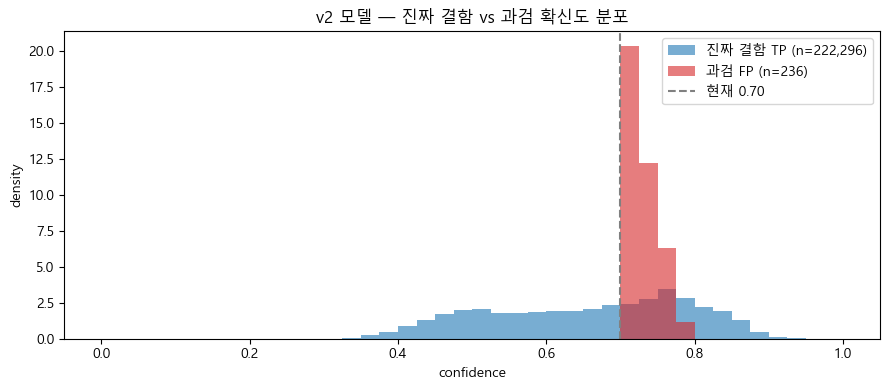

In [12]:
tp_conf, fp_conf = [], []

# 결함 이미지: 모델 예측 ∧ GT 결함 = TP 픽셀의 확신도
for _, r in defect_df.iterrows():
    cls, prob = predict(r['img'])
    gt = cv2.imread(str(r['mask']), cv2.IMREAD_GRAYSCALE)
    conf = prob.max(0)
    tp_conf.extend(conf[(cls > 0) & (gt > 0)].tolist())

# 정상품 이미지: 후처리(min_conf=0.7) 후 남은 FP 블롭의 확신도
for _, r in ok_df.iterrows():
    cls, prob = predict(r['img'])
    conf = prob.max(0)
    fp_mask = postprocess_v2(cls, prob, min_conf=0.7) > 0
    fp_conf.extend(conf[fp_mask].tolist())

tp_conf, fp_conf = np.array(tp_conf), np.array(fp_conf)
desc = lambda a: {k: round(float(v), 3) for k, v in pd.Series(a)
                .describe()[['mean', '25%', '50%', '75%', 'max']].items()}
print(f'진짜 결함 TP 확신도 (n={len(tp_conf):,}): {desc(tp_conf)}')
print(f'과검   FP 확신도 (n={len(fp_conf):,}): {desc(fp_conf)}')

plt.figure(figsize=(9, 4))
plt.hist(tp_conf, bins=40, range=(0, 1), density=True, alpha=0.6,
        color='tab:blue', label=f'진짜 결함 TP (n={len(tp_conf):,})')
plt.hist(fp_conf, bins=40, range=(0, 1), density=True, alpha=0.6,
        color='tab:red',  label=f'과검 FP (n={len(fp_conf):,})')
plt.axvline(0.70, color='gray', ls='--', label='현재 0.70')
plt.xlabel('confidence'); plt.ylabel('density')
plt.title('v2 모델 — 진짜 결함 vs 과검 확신도 분포')
plt.legend(); plt.tight_layout()
plt.show()

| 지표 | v1 (06_verification.md) | v2 (09_re_verification.md) | 비고 |
| :--- | :--- | :--- | :--- |
| FP 픽셀 수 | 13,970 | 236 | 59배 감소 - 1차 후처리만으로 대부분 제거됨 |
| FP 피크 위치 | 0.75~0.85 (넓게) | 0.70~0.75 (sharp) | 임계값 미세조정에 민감 |
| FP 분포 폭 | 0.70~0.95 (광범위) | 0.65~0.85 (좁음) | 0.85 이상에는 거의 없음 |
| TP 0.9+ 영역 | 강한 peak | 거의 없음 | v2가 결함을 "약하게" 확신 |

특이점은 TP가 0.9 이상에서 사라졌습니다.
v1에서는 진짜 결함에 모델이 0.9+ 확신을 보였지만, v2는 0.4~0.8에 평탄하게 분포합니다.

v2는 결함을 잡되 강한 확신을 갖지 않습니다. 임계값을 너무 올리면 진짜 결함도 같이 잘려나갑니다.

다음 단계인 스윕 표에서 정량적으로 찾아보겠습니다.

### 3-2-8. min_conf 스윕

In [13]:
# 추론 결과 캐시 — 스윕 비용 절감
ok_cache = [predict(r['img']) for _, r in ok_df.iterrows()]
def_cache = []
for _, r in defect_df.iterrows():
    cls, prob = predict(r['img'])
    gt = cv2.imread(str(r['mask']), cv2.IMREAD_GRAYSCALE)
    def_cache.append((r['name'], cls, prob, gt))

def evaluate(min_conf):
    n_over, over_px = 0, []
    for cls, prob in ok_cache:
        pp = postprocess_v2(cls, prob, min_conf=min_conf)
        px = int((pp > 0).sum())
        over_px.append(px)
        if px > 0:
            n_over += 1
    n_det, pix_recall, missed = 0, [], []
    for name, cls, prob, gt in def_cache:
        pp = postprocess_v2(cls, prob, min_conf=min_conf)
        inter = int(((pp > 0) & (gt > 0)).sum())
        gt_px = int((gt > 0).sum())
        if inter > 0:
            n_det += 1
        else:
            missed.append(name)
        pix_recall.append(inter / gt_px if gt_px else 0.0)
    return n_over, float(np.mean(over_px)), n_det, float(np.mean(pix_recall)), missed

print(f'{"min_conf":>8} | {"과검":>9} {"과검율":>7} {"평균FP":>8} | '
    f'{"결함검출":>9} {"검출율":>7} {"픽셀recall":>9} | 미검 이미지')
print('-' * 95)
for mc in [0.70, 0.75, 0.78, 0.80, 0.82, 0.85, 0.88, 0.90, 0.95]:
    n_over, mean_px, n_det, pr, missed = evaluate(mc)
    miss_txt = '없음' if not missed else ', '.join(m[-8:] for m in missed)
    print(f'{mc:>8.2f} | {n_over:>3}/{len(ok_cache)}장 {n_over/len(ok_cache)*100:>6.1f}% '
        f'{mean_px:>8.0f} | {n_det:>3}/{len(def_cache)}장 {n_det/len(def_cache)*100:>6.1f}% '
        f'{pr*100:>8.1f}% | {miss_txt}')

min_conf |        과검     과검율     평균FP |      결함검출     검출율  픽셀recall | 미검 이미지
-----------------------------------------------------------------------------------------------
    0.70 |   1/24장    4.2%       10 |  13/14장   92.9%     22.9% | 0781_050
    0.75 |   0/24장    0.0%        0 |  11/14장   78.6%     15.4% | 0781_050, 0731_017, 0731_240
    0.78 |   0/24장    0.0%        0 |  11/14장   78.6%     10.9% | 0781_050, 0731_017, 0731_240
    0.80 |   0/24장    0.0%        0 |  10/14장   71.4%      7.8% | 0781_050, 0731_017, 0731_240, 0851_267
    0.82 |   0/24장    0.0%        0 |  10/14장   71.4%      4.9% | 0781_050, 0731_017, 0731_240, 0851_267
    0.85 |   0/24장    0.0%        0 |   7/14장   50.0%      1.7% | 0781_050, 0731_017, 0731_240, 0748_080, 0891_174, 0851_267, 0821_134
    0.88 |   0/24장    0.0%        0 |   4/14장   28.6%      0.5% | 0916_293, 0781_050, 0731_017, 0731_240, 0748_080, 0891_174, 0791_220, 0916_193, 0851_267, 0821_134
    0.90 |   0/24장    0.0%        0 |   4/14장   28.6

스윕 결과가 v1과 매우 흥미로운 대조를 보입니다. 그리고 결정적 분기점이 명확해졌습니다.

  v1 vs v2 운영점 비교 (동일 후처리 기준)

| 모델 | 운영점 | min_conf | 과검 | 검출 | 픽셀 recall | 미검 |
| :--- | :--- | :--- | :--- | :--- | :--- |:--- |
| v1 | 기본 | min_conf=0.85 | 8.3% (2/24) | 92.9% (13/14) | 29.9% | 0781_050 |
| v1 | GT 제외 | min_conf=0.85 | 8.3% (2/24) | 100% (13/13) | 29.9% | 없음 |
| v2 | A - 검출 우선 | min_conf=0.70 | 4.2% (1/24) | 92.9% (13/14) | 22.9% | 0781_050 |
| v2 | A - GT 제외 | min_conf=0.70 | 4.2% | 100% | 22.9% | 없음 |
| v2 | B - 과검 0% 우선 | min_conf=0.75 | 0.0% | 78.6% | 15.4% | 0781_050, 0731_017, 0731_240 |

- 운영점 A (0.70): 검출률 우선. 미검 1장은 GT 오류 의심 → 제외 시 검출 100%, 과검 4.2%
- 운영점 B (0.75): 과검 0% 우선. 단 미검 3장 발생 — 진짜 미검이면 채택 불가

---
핵심 발견 3가지

1. v2의 과검 억제력이 v1보다 강합니다.
v1은 0.85까지 올려야 과검 8.3%였는데, v2는 0.70에서 이미 4.2%, 0.75에서 0% 입니다.

2. v2의 검출이 임계값에 민감합니다.
0.70 → 0.75 한 칸 올렸을 뿐인데 검출이 92.9% → 78.6%로 14%p 하락. 분포 분석에서 본 TP가 0.4~0.8에 평탄한 특성이 그대로 드러납니다.
v1의 안전 마진(0.75~0.85에서 100% 검출 유지)이 v2엔 없습니다.

3. 픽셀 recall은 v2가 더 낮습니다 (v1 29.9% → v2 22.9%).
v2는 결함을 "발견은 하되 영역의 작은 부분만 마킹"합니다.
그런데 검사 공정에서 1순위는 결함 유무 판정(instance recall) 이지 마킹 정확도가 아닙니다.
instance recall은 v1·v2 동일하게 92.9%입니다.

### 3-2-9. min_conf=0.75 미검 3장 GT 검증


[RGB_cell_cylindrical_0781_050]  CSV라벨=pollution  GT: Pollution=472px, Damaged=0px  모델: P=401px, D=3423px


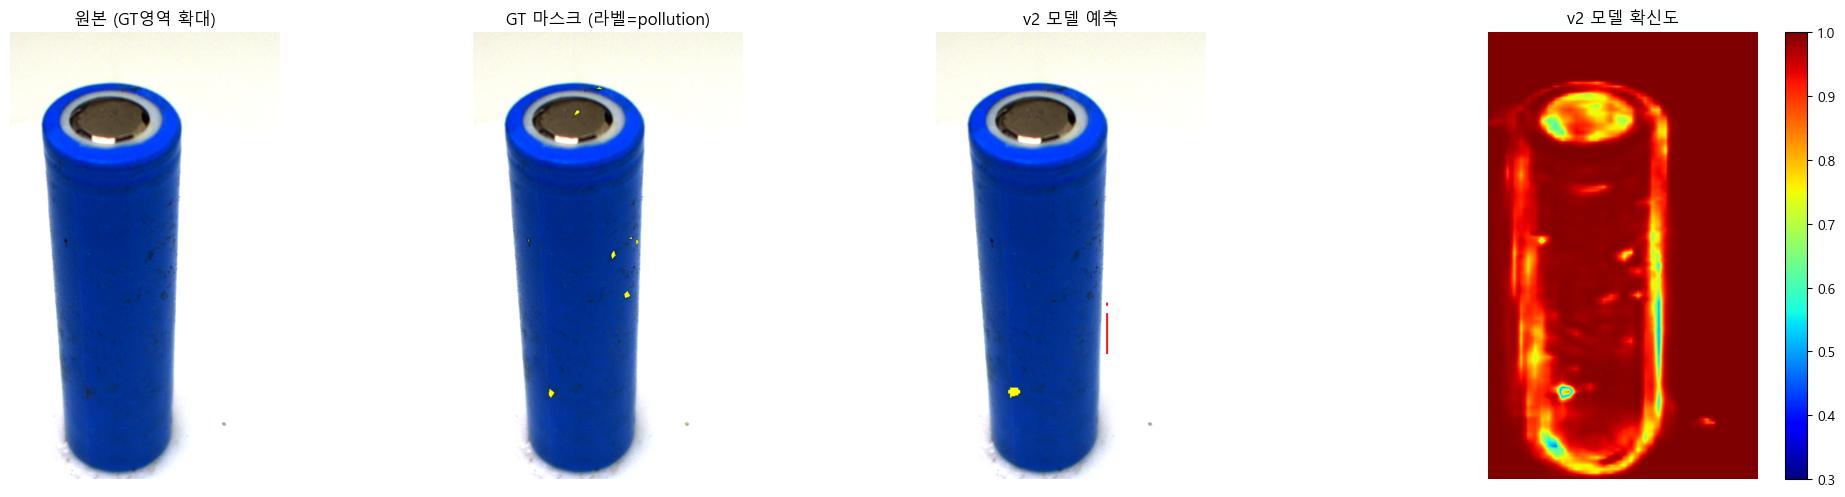


[RGB_cell_cylindrical_0731_017]  CSV라벨=pollution  GT: Pollution=21508px, Damaged=0px  모델: P=8711px, D=4659px


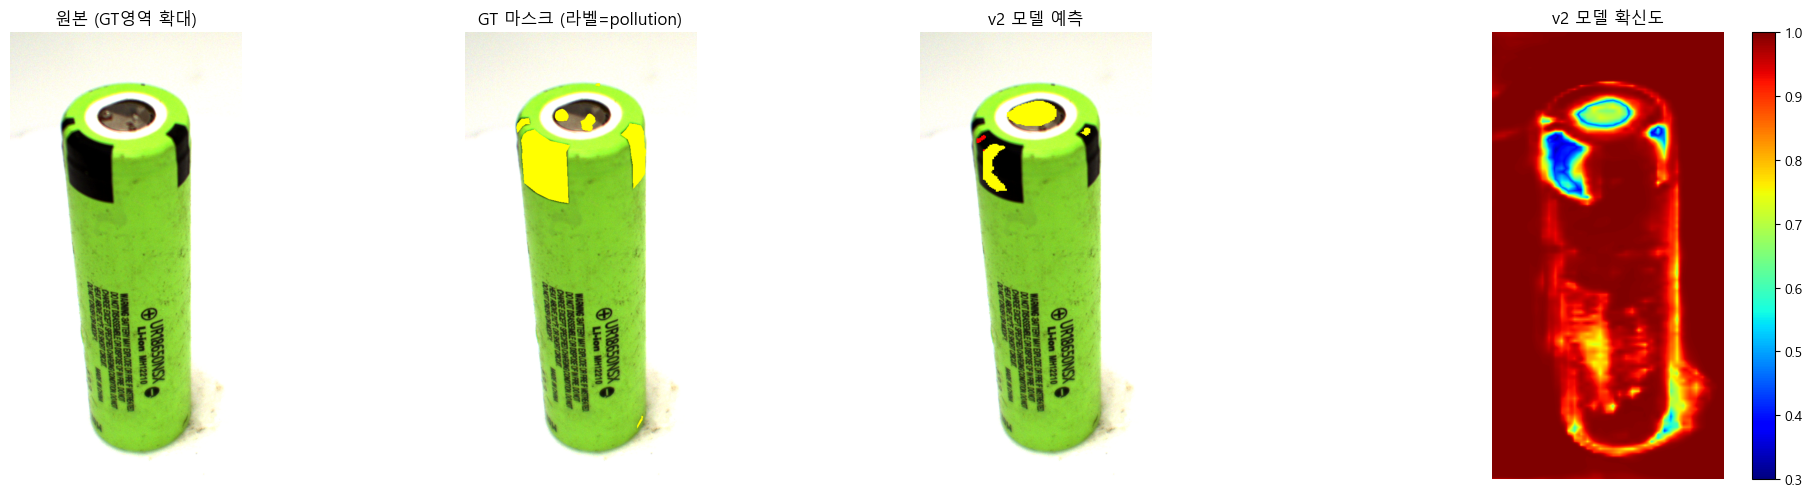


[RGB_cell_cylindrical_0731_240]  CSV라벨=pollution  GT: Pollution=5797px, Damaged=0px  모델: P=6832px, D=3248px


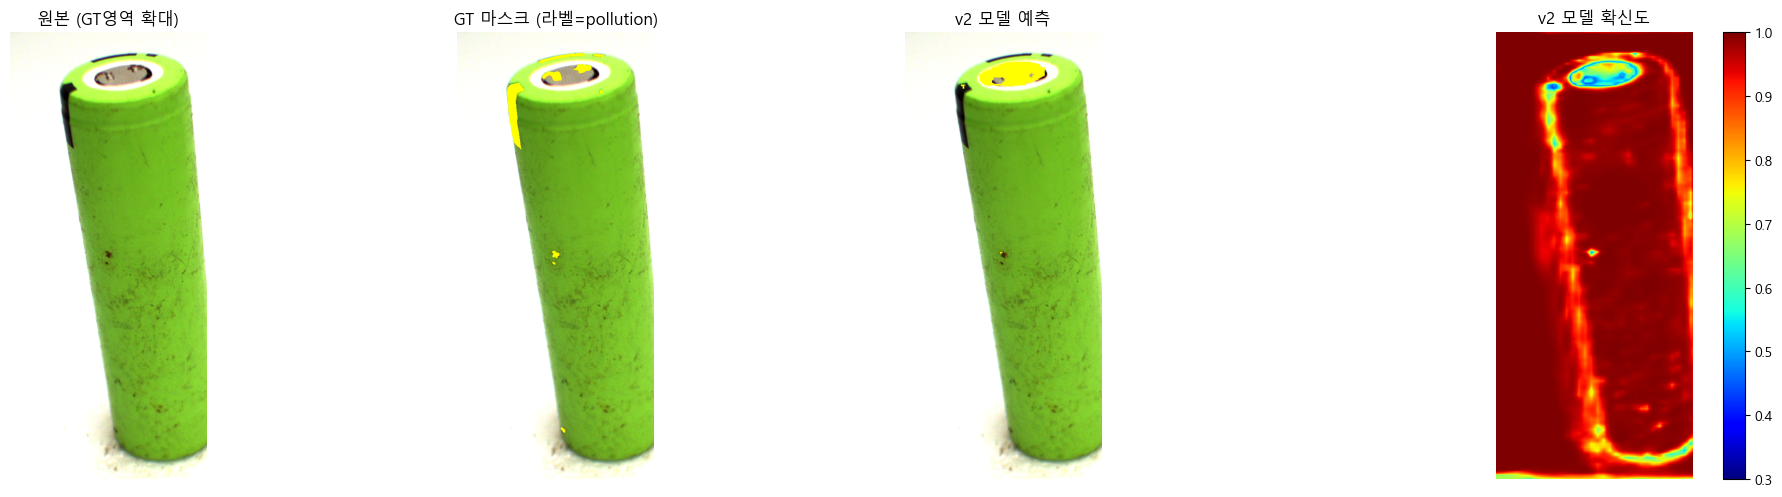

In [14]:
audit_names = [
    'RGB_cell_cylindrical_0781_050',   # nb06: GT 오류 확정 — v2 재확인
    'RGB_cell_cylindrical_0731_017',   # nb06: 모델 약점 확정 — v2 재확인
    'RGB_cell_cylindrical_0731_240',   # 이번에 신규 검증
]

for name in audit_names:
    p   = IMG_DIR  / f'{name}.png'
    img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
    gt  = cv2.imread(str(MASK_DIR / f'{name}.png'), cv2.IMREAD_GRAYSCALE)
    cls, prob = predict(p)
    conf = prob.max(0)

    lab = df.loc[df['name'] == name, 'label'].values
    lab = lab[0] if len(lab) else '(없음)'

    # GT 결함 영역으로 확대
    ys, xs = np.where(gt > 0)
    if len(ys):
        m = 120
        y0, y1 = max(0, ys.min()-m), min(img.shape[0], ys.max()+m)
        x0, x1 = max(0, xs.min()-m), min(img.shape[1], xs.max()+m)
    else:
        y0, y1, x0, x1 = 0, img.shape[0], 0, img.shape[1]

    gt_ov = img.copy()
    gt_ov[gt == 1]  = (255, 255, 0); gt_ov[gt == 2]  = (255, 0, 0)
    pr_ov = img.copy()
    pr_ov[cls == 1] = (255, 255, 0); pr_ov[cls == 2] = (255, 0, 0)

    print(f'\n[{name}]  CSV라벨={lab}  '
        f'GT: Pollution={int((gt==1).sum())}px, Damaged={int((gt==2).sum())}px  '
        f'모델: P={int((cls==1).sum())}px, D={int((cls==2).sum())}px')

    fig, ax = plt.subplots(1, 4, figsize=(20, 5))
    ax[0].imshow(img[y0:y1, x0:x1]);   ax[0].set_title('원본 (GT영역 확대)')
    ax[1].imshow(gt_ov[y0:y1, x0:x1]); ax[1].set_title(f'GT 마스크 (라벨={lab})')
    ax[2].imshow(pr_ov[y0:y1, x0:x1]); ax[2].set_title('v2 모델 예측')
    im = ax[3].imshow(conf[y0:y1, x0:x1], cmap='jet', vmin=0.3, vmax=1.0)
    ax[3].set_title('v2 모델 확신도')
    for a in ax:
        a.axis('off')
    plt.colorbar(im, ax=ax[3], fraction=0.046)
    plt.tight_layout()
    plt.show()

### 3-2-10. 미검 3장 GT 육안 판정 종합

스윕 표에서 운영점을 결정하기 위해 미검 후보 3장을 원본 확대 + 확신도 맵으로 도메인 관점에서 육안 검증하였습니다. 결과는 다음과 같습니다.

| 이미지 | 라벨 | GT (P/D px) | v2 예측 (P/D px) | 육안 판정 | 의미 |
| :--- | :--- | :--- | :--- | :--- | :--- |
| `0731_017` | pollution | 21508 / 0 | 8711 / 4659 | 캡 영역 변색 확인 — **GT 정상** | 모델이 부분만 잡음 (under-coverage) — 진짜 한계 |
| `0731_240` | pollution | 5797 / 0 | 6832 / 3248 | 변색 진위 애매 — **경계 케이스** | 모델 위치 매칭은 양호, 픽셀 단위 미세 차이로 inter=0 |
| `0781_050` | pollution | 472 / 0 | 401 / 3423 | 결함은 아니나 미세 오염 — **경계 케이스** | GT 영역이 14장 중 최소(472px), 모델·사람 모두 판정 어려움 |

세 이미지 모두 명백한 GT 오류는 없는 것으로 판정되었습니다. `0731_240`·`0781_050`은 도메인 전문가도 즉답이 어려운 경계 케이스로, 본 검증 데이터셋의 라벨 일관성 한계를 함께 보여줍니다.

따라서 미검 1장을 가짜 미검으로 처리하기보다 **현 데이터에서 도달 가능한 한계 운영점을 그대로 채택**합니다.

| 운영점 후보 | min_conf | 과검율 | Instance Recall | 미검 |
| :--- | :--- | :--- | :--- | :--- |
| A (검출 우선) | **0.70** | **4.2% (1/24)** | **92.9% (13/14)** | `0781_050` (미세 오염) |
| B (과검 0% 우선) | 0.75 | 0.0% (0/24) | 78.6% (11/14) | 위 3장 모두 |

본 노트북은 검사 공정의 1차 목표(OK/NG 판정 신뢰도)에 따라 **운영점 A (min_conf=0.70)** 를 채택합니다.

## 4. 검증 종합 및 회고

### 4-1. v2 검증 결과

`battery_deeplab_v2.onnx` + `postprocess_v2(min_conf=0.70)`를 test 셋 38장(정상품 24 + 결함 14)으로 전수 검증한 결과는 다음과 같습니다.

| 지표 | v1 (raw) | v1 + 후처리 (0.85) | **v2 + 후처리 (0.70)** | v2 개선폭 |
| :--- | :--- | :--- | :--- | :--- |
| 정상품 과검율 | 100% (24/24) | 8.3% (2/24) | **4.2% (1/24)** | v1 후처리 대비 약 절반 |
| 평균 오검 픽셀 | 6,831 | 30 | **10** | v1 후처리 대비 3배↓ |
| Instance Recall | 92.9% | 92.9% | **92.9%** | 동일 |
| Pixel Recall | — | 29.9% | 22.9% | 일부 감소 |

- **과검 억제력**: v2의 raw 예측은 Damaged 노이즈 floor로 인해 v1과 유사해 보였으나, **확신도 후처리 적용 시 FP 픽셀이 v1의 13,970 → v2의 236으로 약 60배 감소**했습니다. v1보다 낮은 임계값(0.70)에서 v1의 0.85 운영점 이상의 과검 성능을 달성합니다.
- **검출률**: 두 모델 모두 Instance Recall 92.9%로 동일합니다. 미검 1장(`0781_050`)은 GT 472px의 매우 미세한 오염으로, 도메인 전문가도 판정이 어려운 경계 케이스입니다.
- **Pixel Recall 감소**(29.9% → 22.9%)는 v2가 결함을 "발견은 하되 작은 영역만 마킹"하는 경향에서 비롯됩니다. 검사 공정의 1차 목표인 OK/NG 판정에는 영향이 없습니다(Instance Recall 동일).

### 4-2. 파인튜닝 개선 과정 회고

본 프로젝트의 모델 개선은 **숫자 지표만이 아니라 육안 검증과 도메인 판정을 함께 활용한 반복 사이클**로 진행되었습니다.

| 단계 | 모델 / 실험 | 핵심 결정 | 결정 근거 |
| :--- | :--- | :--- | :--- |
| 1차 | AI허브 raw (v1) | 후처리 + min_conf=0.85 채택 | 정량 스윕 + GT 오류 1장 육안 식별 |
| 2차 | fine-tune (CE, 30배 weight) | 폐기 | 정상품 24장 모두 과검 (100%) — 정량으로 즉시 식별 |
| 3차 | fine-tune (CE+Dice, 5배 weight) | 폐기 | Instance Recall 0.116 — **육안 검사에서 결함 88% 누락** 확인 |
| 4차 | **fine-tune v2 (CE, 20배 weight)** | **운영 채택** | 정량 우위 + 미검 3장 육안 검증으로 GT 라벨 일관성까지 분리 검증 |

**완벽한 모델은 아닙니다.** 미세 오염(`0781_050`)을 놓치고, Damaged 클래스는 노이즈 floor를 만들며, Pixel Recall은 v1보다 다소 낮습니다. 다만 본 데이터셋(174장 학습, Damaged 픽셀 0.12%)과 학습 자원(decoder 3.2%만 학습)의 제약 안에서 **검사 공정의 1차 목표인 OK/NG 선별 신뢰도를 확보한 운영점**이라고 판단합니다.

### 4-3. 한계와 향후 개선 방향

본 모델에서 확인된 구조적 한계는 다음과 같습니다.

| 한계 | 원인 | 후속 개선 방향 |
| :--- | :--- | :--- |
| Damaged 클래스 노이즈 floor | 픽셀 비율 0.12% — 클래스 가중치 상한에 걸려 Pollution과 동일 weight로 수렴 | 데이터 추가 수집으로 0.3%+ 확보 후 3-class 재학습 |
| Pixel Recall 22.9% | 결함 영역의 부분만 마킹 | 2-class(bg/defect) 재학습 — `10_re_finetune_v3_colab.ipynb` 학습은 완료, 본 검증 적용은 후속 작업으로 분리 |
| 캡 영역 과민 반응 | ColorJitter 증강이 캡 림 음영 변화에 모델을 민감하게 학습 | ROI mask 도입 또는 ColorJitter 강도 감소 |
| 학습 범위 제한 | Backbone + ASPP 동결로 학습 capacity 3.2% | ASPP 동결 해제 비교 실험 |

검사 공정의 비즈니스 요구사항이 "결함 type 분류"까지 확장될 경우 위 후속 작업을 진행합니다. 현재 데이터·자원에서는 **v2 + 후처리 파이프라인이 도달 가능한 운영점**입니다.

### 4-4. 모델 아키텍처 선정 회고 및 후속 학습 방향

본 프로젝트에서 DeepLabV3+를 사용한 1차 이유는 **AI허브 공개 사전학습 가중치가 DeepLabV3+(DRN-D-54 backbone) 기반이었기 때문**입니다. 도메인 데이터가 174장으로 매우 적은 상황에서 산업 검사 도메인의 사전학습 가중치를 활용할 수 있다는 점이 결정적이었습니다.

실제로 본 프로젝트를 진행하며 확인한 DeepLabV3+의 장점은 다음과 같습니다.

| 구성 요소 | 기능 | 본 프로젝트에서의 효과 |
| :--- | :--- | :--- |
| Atrous Convolution | 해상도 손실 없이 receptive field 확장 | 1920×1080 고해상도 결함 이미지에서 미세 결함의 위치 정보 유지 |
| ASPP (Atrous Spatial Pyramid Pooling) | multi-scale feature 추출 | Pollution(작은 점부터 큰 영역까지)·Damaged 크기 편차에 강건 |
| Encoder-Decoder 구조 | 정밀한 객체 경계 복원 | 셀 캡·림 같은 구조물 경계 인식 |
| ONNX 호환성 | 표준 export 지원 | C# 데모 환경 배포 용이 (`Postprocessor.cs`와 동일 전처리 재현) |

다만 본 프로젝트의 경험을 바탕으로 추후 다음 segmentation 모델들도 학습·비교 실험을 진행하고자 합니다.

- **U-Net 계열**: 의료영상 segmentation 표준 아키텍처. 적은 데이터에서 안정적 학습이 장점. 본 데이터셋 규모(174장)에 더 적합할 가능성 검증 필요.
- **SegFormer / Mask2Former**: Transformer 기반 segmentation. CNN 대비 글로벌 컨텍스트 활용. 캡 영역 과민 반응 같은 국소 편향을 완화할 가능성.
- **YOLOv8-seg / v11-seg**: 실시간 추론에 최적화된 구조. 검사 라인 tact time 제약이 있는 운영 환경에서 검토 가치.

### 4-5. 본 프로젝트 정리

본 프로젝트는 단일 모델 학습이 아니라 **공개 가중치 활용 → fine-tune 실험 → 검증 → 후처리 튜닝 → 배포 환경 이식**까지 운영 사이클 전 구간을 다뤘습니다.
이 과정에서 다음을 확인하였습니다.

- **데이터 한계 진단이 모델 튜닝보다 우선**입니다. Damaged 픽셀 0.12% 희소성은 클래스 가중치 조정 3회로 해결되지 않았고, 추가 데이터 수집 권고로 결론지었습니다. 무리한 학습보다 한계를 정직하게 정리하는 것이 운영 환경에서 더 가치 있다고 판단합니다.
- **정량 지표와 육안 검증의 병행**이 필수입니다. GT 라벨 오류·경계 케이스는 숫자만으로 식별되지 않으며, 도메인 판정과 결합해야 운영 가능한 결정에 도달합니다.
- **운영 파이프라인은 모델 + 후처리의 합**입니다. raw 모델 출력만 비교하면 v2가 v1과 유사해 보였으나, 동일한 후처리 기준에서는 v2가 FP 픽셀 60배 우위였습니다. 모델 단독 평가는 운영 의사결정에 부적합합니다.

추후 산업 현장에서는 새로운 segmentation 모델을 학습·평가·배포하는 사이클에 본 경험을 직접 적용하고, 데이터 품질 관리와 모델 모니터링까지 일관된 운영 파이프라인으로 확장할 수 있을 것이라 판단합니다.